In [1]:
import os
from xspec import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from decimal import Decimal

Xset.allowPrompting = False # keeps pyxspec from hanging, waiting for a response to a prompt

<span style='color:green'> Here I Fit only TM1. First I load the data  </span>

In [2]:
AllData.clear()
path="/Users/marcotaoso/Documents/2024/eROSITA/FromJorge/LMC_test_3deg/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/"
filespectrum=path+"srctoolout_120_SourceSpec_00001.fits"
fileRMF=path+"srctoolout_120_RMF_00001.fits"
fileARF=path+"srctoolout_120_ARF_00001.fits"
#
s1 = Spectrum(filespectrum)
s1.response=fileRMF
s1.response.arf=fileARF

# check the data
AllData.show()


 response file  read skipped

1 spectrum  in use
 
Spectral Data File: /Users/marcotaoso/Documents/2024/eROSITA/FromJorge/LMC_test_3deg/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/srctoolout_120_SourceSpec_00001.fits  Spectrum 1
Net count rate (cts/s) for Spectrum:1  1.582e+00 +/- 4.115e-03
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-1024
  Telescope: eROSITA Instrument: TM1  Channel Type: PI
  Exposure Time: 9.345e+04 sec
 Using fit statistic: chi
 No response loaded.

***Warning!  One or more spectra are missing responses,
               and are not suitable for fit.
Response successfully loaded.
Arf successfully loaded.

1 file 1 spectrum 
Spectrum 1  Spectral Data File: /Users/marcotaoso/Documents/2024/eROSITA/FromJorge/LMC_test_3deg/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/srctoolout_120_SourceSpec_00001.fits
Net count rate (cts/s) for Spectrum:1  1.582e+00 +/- 4.115e-03
 Assigned to Data Group 1 and Plot Group 1
  Notice

Error: cannot read response file srctoolout_120_RMF_00001.fits


NOW LOAD the Sigma of EROSITA. At the moment I take the FWHM from https://erosita.mpe.mpg.de/edr/eROSITATechnical/calibration.html
Computing \sigma=FWHM/2.355 I find that \sigma ranges from [33,72] eV and E/sigma = [34,139] for E ranging from 1 to 10 keV. 
This is >> sigmav = c/v = 1360 for v=220 km/s.
Larger than intrinsic/Doppler width of astro lines???

In [3]:
vE = np.array([1.,10.])
vFWHM = np.array([0.070,0.165]) #keV
vsigma = vFWHM/(2.355)

<span style='color:green'> Fix the energy of the DM line and select data </span>

In [4]:
# I do not consider eROSITA data outside this range
Eallmin = 0.3
Eallmax = 9.

Eline = 1.31037 #4.73 #0.689357

sigma = np.interp(Eline,vE,vsigma)
print("Eline ",Eline," sigma ",sigma)
Emin= Eline - 5*sigma
Emax= Eline + 5*sigma
if(Emin<Eallmin):
    Emin=Eallmin
if(Emax>Eallmax):
    Emax=Eallmax
print("Emin ",Emin," Emax ",Emax)
str_range = "**-"+str(round(Emin, 4))+",,"+str(round(Emax, 4))+"-**"
print(str_range)
AllData.ignore(str_range)
#
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()
energies = np.asarray(Plot.x())
edeltas = np.asarray(Plot.xErr())
rates = np.asarray(Plot.y())
errors = np.asarray(Plot.yErr())
print("***************")
print("Selected values ",np.min(energies)," ",np.max(energies)," Nbins ",len(energies))
print("***************")

Eline  1.31037  sigma  0.03111512856805851
Emin  1.1547943571597075  Emax  1.4659456428402926
**-1.1548,,1.4659-**
Plot command list is now empty
***************
Selected values  1.1630913615226746   1.457366168498993  Nbins  39
***************
   172 channels (1-172) ignored in spectrum #     1
   813 channels (212-1024) ignored in spectrum #     1



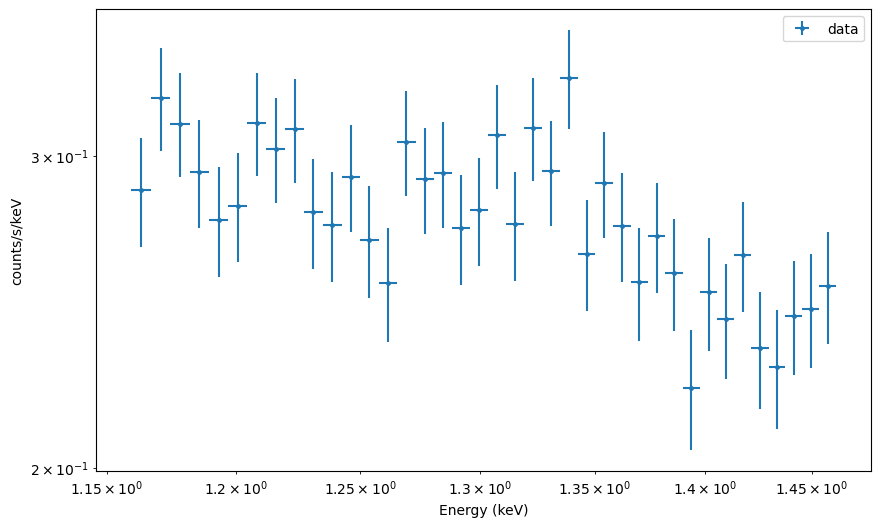

In [6]:
#ax.clear()
fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

Now I consider the Astro and Internal Background lines falling into the energy range +- 7 sigma.
At the end I define arrays containing the position of the lines and the min and max values inside which they can fluctuate in the fit

In [7]:
EminL = Eline - 7*sigma
EmaxL = Eline + 7*sigma
if(EminL<Eallmin):
    EminL = Eallmin
if(EmaxL>Eallmax):
    EmaxL = Eallmax

data = np.loadtxt("/Users/marcotaoso/Documents/2024/eROSITA/IB_FWC/IBLines.txt",skiprows=0)
IBenergy = data[:,0]
IBenergymin = data[:,1]
IBenergymax = data[:,2]
data = np.loadtxt("/Users/marcotaoso/Documents/2024/eROSITA/AstroLines/AstroLines.txt",skiprows=0)
Aenergy = data[:,0]
Aenergymin = data[:,1]
Aenergymax = data[:,2]
#print(Aenergy," ",IBenergy)
#print(len(Aenergy)," ",len(IBenergy))
IBidx = np.where( (IBenergy > EminL ) & (IBenergy < EmaxL ) )
Aidx = np.where( (Aenergy > EminL ) & (Aenergy < EmaxL ) )
IBLine = IBenergy[IBidx]
IBLinemin = IBenergymin[IBidx]
IBLinemax = IBenergymax[IBidx]
ALine = Aenergy[Aidx]
ALinemin = Aenergymin[Aidx]
ALinemax = Aenergymax[Aidx]
IBn = len(IBLine)
An = len(ALine)
IBAn = IBn + An
IBALine = np.concatenate((IBLine, ALine))
IBALinemin = np.concatenate((IBLinemin, ALinemin))
IBALinemax = np.concatenate((IBLinemax, ALinemax))
idx = np.argsort(IBALine)
IBALine = IBALine[idx]
IBALinemin = IBALinemin[idx]
IBALinemax = IBALinemax[idx]
print("Total lines ",IBAn," IB ",IBn," A ",An)
print(IBALine," IB ",IBLine," A ",ALine)
print(IBALinemin," ",IBALinemax)

Total lines  1  IB  1  A  0
[1.48585]  IB  [1.48585]  A  []
[1.47]   [1.5]


<span style='color:green'> Define the model </span>

In [8]:
# load the model into XSPEC

baseM = "powerlaw+powerlaw+powerlaw+gaussian"
linesM = ""
for i in range(0,IBAn):
    linesM= linesM+"+gaussian"
finalM = baseM + linesM
print("Final Model ",finalM)
AllModels.clear()
mpoly = Model(finalM,"mpoly",1)

# COMPUTE norm of the line to hit data
# to have an idea of a sensible normalization
arf1test = fits.open(fileARF)['SPECRESP']
arf1ELOW = arf1test.data.field('ENERG_LO')#keV
arf1EHI = arf1test.data.field('ENERG_HI')#keV
arf1Aeff = arf1test.data.field('SPECRESP')#cm2
arf1E = (arf1ELOW + arf1EHI)/2.
Aefftest = np.interp(Eline, arf1E, arf1Aeff)
Ratetest = np.interp(Eline, energies, rates)
normlDMhdata = Ratetest/Aefftest
print("normlDMhdata ",normlDMhdata)

#Power law
mpoly.powerlaw.PhoIndex = 0.
mpoly.powerlaw.PhoIndex.frozen = True
mpoly.powerlaw_2.PhoIndex = 1.
mpoly.powerlaw_2.PhoIndex.frozen = True
mpoly.powerlaw_3.PhoIndex = 2.
mpoly.powerlaw_3.PhoIndex.frozen = True

# SET DM line and freeze
sigmaDM = Eline* 220/3e5 #1e-4
mpoly.gaussian.LineE = Eline
mpoly.gaussian.LineE.frozen = True
mpoly.gaussian.Sigma = sigmaDM
mpoly.gaussian.Sigma.frozen = True
# normalization in photons/cm$^2$/s in the line
mpoly.gaussian.norm = 0.
mpoly.gaussian.norm.frozen = True
print(mpoly.gaussian.LineE.values)


for _name in mpoly.componentNames:
    #print(_name)
    if (_name.startswith("gaussian_") and int(_name.split('_')[-1]) <= 30):
        print(_name)
        indexl = int(_name.split('_')[-1]) - 5 # 1,2,3 are pl, 4 is DM line
        print(indexl)
        _comp = mpoly.__getattribute__(_name)
        #print(_comp)
        _comp.LineE.values = [float(IBALine[indexl]), float(IBALine[indexl])*1e-2, float(IBALinemin[indexl]), float(IBALinemin[indexl]), float(IBALinemax[indexl]), float(IBALinemax[indexl])]
        #print(_comp.LineE.values)
        _comp.LineE.frozen = True
        _comp.Sigma.values = 0.0001
        _comp.Sigma.frozen = True
        _comp.norm.values = 0.0
        _comp.norm.frozen = True


Xset.chatter = 10
AllModels.show()
Xset.chatter = 2

Final Model  powerlaw+powerlaw+powerlaw+gaussian+gaussian

Model mpoly:powerlaw<1> + powerlaw<2> + powerlaw<3> + gaussian<4> + gaussian<5> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            1.00000      +/-  0.0          
   2    1   powerlaw   norm                1.00000      +/-  0.0          
   3    2   powerlaw   PhoIndex            1.00000      +/-  0.0          
   4    2   powerlaw   norm                1.00000      +/-  0.0          
   5    3   powerlaw   PhoIndex            1.00000      +/-  0.0          
   6    3   powerlaw   norm                1.00000      +/-  0.0          
   7    4   gaussian   LineE      keV      6.50000      +/-  0.0          
   8    4   gaussian   Sigma      keV      0.100000     +/-  0.0          
   9    4   gaussian   norm                1.00000      +/-  0.0          
  10    5   gaussian   LineE      keV      6.50000      +/-  0.0          
  11    5   gaussian   Si

In [9]:
# START FITTING WITH NO LINES AT ALL
print("Test Statistics ",Fit.statistic," testStatistics ",Fit.testStatistic)
Fit.statMethod = "cstat"
#Fit.method = "migrad"
Fit.nIterations=10000
Fit.perform()
Fit.perform()
Fit.perform()
Fit.perform()
TSnolines = Fit.statistic
dofnolines = Fit.dof
print("Test Statistics ",TSnolines," testStatistics ",Fit.testStatistic," dof ",dofnolines," nVarPars ",Fit.nVarPars)

Xset.chatter=10
AllModels.show()
Fit.show()
Xset.chatter = 1
#https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/node118.html#method
#https://heasarc.gsfc.nasa.gov/docs/xanadu/xspec/python/html/fitmanager.html
# leven
#Test Statistics  1347.0064027516084  testStatistics  1302.6655727029292  dof  42  nVarPars  3
# migrad
#Test Statistics  1347.0075618694448  testStatistics  1302.6664515924138  dof  42  nVarPars  3

Test Statistics  7005804.2960522445  testStatistics  7005804.2960522445
Test Statistics  39.87899304327084  testStatistics  39.22172817725264  dof  36  nVarPars  3

Parameters defined:
Model mpoly:powerlaw<1> + powerlaw<2> + powerlaw<3> + gaussian<4> + gaussian<5> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            0.0          frozen
   2    1   powerlaw   norm                3.53936E-04  +/-  0.208114     
   3    2   powerlaw   PhoIndex            1.00000      frozen
   4    2   powerlaw   norm                7.95791E-02  +/-  0.546076     
   5    3   powerlaw   PhoIndex            2.00000      frozen
   6    3   powerlaw   norm                2.58713E-02  +/-  0.356428     
   7    4   gaussian   LineE      keV      1.31037      frozen
   8    4   gaussian   Sigma      keV      9.60938E-04  frozen
   9    4   gaussian   norm                0.0          frozen
  10    5   gaussian   LineE      keV      1.4

In [12]:
loopfit = 100
thresholdfit =0.01
# INTRODUCE ASTRO LINES one by one
# At this stage the DM line is still set to zero
THretainlines = 4
IBAnSign = 0
indexSign = []
TSbase = TSnolines
for _name in mpoly.componentNames:
    if (_name.startswith("gaussian_") and int(_name.split('_')[-1]) <= 30):
        #print(_name)
        indexl = int(_name.split('_')[-1]) - 5 # 1,2,3 are pl, 4 is DM line
        #print(indexl)
        _comp = mpoly.__getattribute__(_name)
        #print(_comp)
        _comp.norm.frozen = False
        _comp.LineE.frozen = False
        #print(_comp.norm.values)
        #print(_comp.LineE.values)
        Fit.statMethod = "cstat"
        #Fit.method = "migrad"
        Fit.nIterations=10000
        #
        Fit.perform()
        Fit.perform()
        Fit.perform()
        Fit.perform()
        TSbase2 = Fit.statistic
        dofnew = Fit.dof
        #loopfit = 20000
        #thresholdfit =0.0005
        for i in range(0,loopfit):
            #print(i)
            Fit.perform()
            Fit.perform()
            Fit.perform()
            Fit.perform()
            Fit.perform()
            TSnew = Fit.statistic
            #dofnoDM = Fit.dof
            if(TSbase2 - TSnew <thresholdfit):
                break
        DeltaTS = TSbase - TSnew 
        if( DeltaTS > 4):
            IBAnSign = IBAnSign + 1
            indexSign.append(int(_name.split('_')[-1]))
        TSbase = TSnew

print("Test Statistics ",TSbase," testStatistics ",Fit.testStatistic," dof ",dofnew," nVarPars ",Fit.nVarPars)
print("IBAnSign ",IBAnSign)
print(indexSign)

loopfit = 1000
thresholdfit =0.001
# AFTER the loop above all the astro lines are free
# Now iteratively I set a line to zero (and freeze it) and I see if the \DeltaTS decreases significantly.
# If yes, the line is significant:  I add it to the array indexSign and I free the line
# At the end of the loop indexSign should contain the index of significant lines
IBAnSign = 0
Tfinal = TSbase # TS of previous fit (and of the loop)
indexSign = []
for _name in mpoly.componentNames:
    if (_name.startswith("gaussian_") and int(_name.split('_')[-1]) <= 30):
        print(_name)
        indexl = int(_name.split('_')[-1]) - 5 # 1,2,3 are pl, 4 is DM line
        #print(indexl)
        _comp = mpoly.__getattribute__(_name)
        #set to zero and freeze
        _comp.norm = 0.0
        _comp.norm.frozen = True
        _comp.LineE.frozen = True
        #print(_comp.norm.values)
        #print(_comp.LineE.values)
        Fit.statMethod = "cstat"
        #Fit.method = "migrad"
        Fit.nIterations=10000
        #
        Fit.perform()
        Fit.perform()
        Fit.perform()
        Fit.perform()
        TSbase2 = Fit.statistic
        dofnew = Fit.dof
        #loopfit = 20000
        #thresholdfit =0.0005
        for i in range(0,loopfit):
            #print(i)
            Fit.perform()
            Fit.perform()
            Fit.perform()
            Fit.perform()
            Fit.perform()
            TSnew = Fit.statistic
            #dofnoDM = Fit.dof
            if(TSbase2 - TSnew <thresholdfit):
                break
        #Fit.perform()
        #Fit.perform()
        #Fit.perform()
        #Fit.perform()
        #TSnew = Fit.statistic
        #dofnew = Fit.dof
        #print(_comp.norm.values)
        #print(_comp.LineE.values)
        DeltaTS = TSnew - Tfinal 
        print(TSnew," ",Tfinal," ",DeltaTS)
        if( DeltaTS > 4):
            IBAnSign = IBAnSign + 1
            indexSign.append(int(_name.split('_')[-1]))
            #allow to fluctuate again
            _comp.norm.frozen = False
            _comp.LineE.frozen = False

print("Test Statistics ",TSnew," testStatistics ",Fit.testStatistic," dof ",dofnew)
print("IBAnSign ",IBAnSign)
print(indexSign)


#Test Statistics  41.91540330224393  testStatistics  42.56069790826645  dof  18  nVarPars  27
#IBAnSign  5
#[5, 6, 9, 14, 15]
#IBAnSign  7
#[8, 9, 10, 11, 12, 13, 15]

Test Statistics  39.878988265962846  testStatistics  39.22357513478267  dof  34  nVarPars  5
IBAnSign  0
[]
gaussian_5
39.86763970071706   39.878988265962846   -0.011348565245782538
Test Statistics  39.86763970071706  testStatistics  39.221374947737516  dof  36
IBAnSign  0
[]


In [13]:
Xset.chatter=10
AllModels.show()
#Fit.show()
Xset.chatter = 1


Parameters defined:
Model mpoly:powerlaw<1> + powerlaw<2> + powerlaw<3> + gaussian<4> + gaussian<5> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            0.0          frozen
   2    1   powerlaw   norm                2.63228E-19  +/-  -1.00000     
   3    2   powerlaw   PhoIndex            1.00000      frozen
   4    2   powerlaw   norm                8.16306E-02  +/-  1.71775E-02  
   5    3   powerlaw   PhoIndex            2.00000      frozen
   6    3   powerlaw   norm                2.38033E-02  +/-  2.23902E-02  
   7    4   gaussian   LineE      keV      1.31037      frozen
   8    4   gaussian   Sigma      keV      9.60938E-04  frozen
   9    4   gaussian   norm                0.0          frozen
  10    5   gaussian   LineE      keV      1.48585      frozen
  11    5   gaussian   Sigma      keV      1.00000E-04  frozen
  12    5   gaussian   norm                0.0          frozen
_____________________

In [11]:
# compute the maximum value of the normalization of all the lines in indexSign
#Maxnormline = 0
#for _name in mpoly.componentNames:
#    if (_name.startswith("gaussian_") and int(_name.split('_')[-1]) <= 30):
        #print(_name)
#        indexl = int(_name.split('_')[-1]) - 5 # 1,2,3 are pl, 4 is DM line
        #print(indexl)
#        _comp = mpoly.__getattribute__(_name)
        #print(_comp)
#        if int(_name.split('_')[-1]) in indexSign:
#            if(Maxnormline < _comp.norm.values[0]):
#                Maxnormline = _comp.norm.values[0]
            
#print("Maxnormline ", Maxnormline)


#for _name in mpoly.componentNames:
#    if (_name.startswith("gaussian_") and int(_name.split('_')[-1]) <= 30):
#        #print(_name)
#        indexl = int(_name.split('_')[-1]) - 5 # 1,2,3 are pl, 4 is DM line
#        #print(indexl)
#        _comp = mpoly.__getattribute__(_name)
#        #print(_comp)
#        if(_comp.norm.values[0] > Maxnormline*1e-3):
#            print(_name)
#            print(_comp.norm.values[0])


In [14]:
loopfit = 20000
thresholdfit =0.001

# Free only astro which are significant 
for _name in mpoly.componentNames:
    if (_name.startswith("gaussian_") and int(_name.split('_')[-1]) <= 30):
        #print(_name)
        indexl = int(_name.split('_')[-1]) - 5 # 1,2,3 are pl, 4 is DM line
        #print(indexl)
        _comp = mpoly.__getattribute__(_name)
        #print(_comp)
        if int(_name.split('_')[-1]) in indexSign:
            _comp.norm.frozen = False
            _comp.LineE.frozen = False
        else:
            _comp.norm.values = 0.0
            _comp.norm.frozen = True
            _comp.LineE.frozen = True

# FIT the astro Model: At this stage the DM line is still set to zero        
Fit.statMethod = "cstat"
#Fit.method = "migrad"
Fit.nIterations=10000
Fit.perform()
Fit.perform()
Fit.perform()
Fit.perform()
Fit.perform()
TSnoDM = Fit.statistic
dofnoDM = Fit.dof
print("Test Statistics ",TSnoDM," testStatistics ",Fit.testStatistic," dof ",dofnoDM," nVarPars ",Fit.nVarPars)
TSbase = TSnoDM
#loopfit = 20000
#thresholdfit =0.001
for i in range(0,loopfit):
    #print(i)
    Fit.perform()
    Fit.perform()
    Fit.perform()
    Fit.perform()
    Fit.perform()
    TSnoDM = Fit.statistic
    dofnoDM = Fit.dof
    #print("Test Statistics ",TSnoDM," testStatistics ",Fit.testStatistic," dof ",dofnolines," nVarPars ",Fit.nVarPars)
    if(TSbase - TSnoDM <thresholdfit):
        break
    TSbase = TSnoDM
print("iterations in the loop ",i," loopfit ",loopfit)
TSnoDM = Fit.statistic
dofnoDM = Fit.dof
print("Test Statistics ",TSnoDM," testStatistics ",Fit.testStatistic," dof ",dofnoDM," nVarPars ",Fit.nVarPars)
Xset.chatter=10
AllModels.show()
Fit.show()
Xset.chatter = 1

# LEVEN
#256  loopfit  20000
#Test Statistics  40.2489456765677  testStatistics  40.98969988730261  dof  24  nVarPars  21

#loop  0  loopfit  20000
#Test Statistics  39.37653597921485  testStatistics  40.153171739312626  dof  28  nVarPars  17

Test Statistics  39.86763970071706  testStatistics  39.221374947737516  dof  36  nVarPars  3
iterations in the loop  0  loopfit  20000
Test Statistics  39.86763970071706  testStatistics  39.221374947737516  dof  36  nVarPars  3

Parameters defined:
Model mpoly:powerlaw<1> + powerlaw<2> + powerlaw<3> + gaussian<4> + gaussian<5> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            0.0          frozen
   2    1   powerlaw   norm                2.63228E-19  +/-  -1.00000     
   3    2   powerlaw   PhoIndex            1.00000      frozen
   4    2   powerlaw   norm                8.16306E-02  +/-  1.71775E-02  
   5    3   powerlaw   PhoIndex            2.00000      frozen
   6    3   powerlaw   norm                2.38033E-02  +/-  2.23902E-02  
   7    4   gaussian   LineE      keV      1.31037      frozen
   8    4   gaussian   Sigma      keV      9.60938E-04  frozen
   9    4   gaussian   norm                0.

In [15]:
# Check if some of the astro lines have best-fit values very small (should not be the case)
# To help the fit I fix these normalization and position of these lines

# compute the maximum value of the normalization of all the lines in indexSign
Maxnormline = 0
for _name in mpoly.componentNames:
    if (_name.startswith("gaussian_") and int(_name.split('_')[-1]) <= 30):
        #print(_name)
        indexl = int(_name.split('_')[-1]) - 5 # 1,2,3 are pl, 4 is DM line
        #print(indexl)
        _comp = mpoly.__getattribute__(_name)
        #print(_comp)
        if int(_name.split('_')[-1]) in indexSign:
            if(Maxnormline < _comp.norm.values[0]):
                Maxnormline = _comp.norm.values[0]


# I fix the lines with normalization < Maxnormline*1e-3 (arbitrary)
print("Maxnormline ", Maxnormline)
IBAnSignsmall = 0
for _name in mpoly.componentNames:
    if (_name.startswith("gaussian_") and int(_name.split('_')[-1]) <= 30):
        #print(_name)
        indexl = int(_name.split('_')[-1]) - 5 # 1,2,3 are pl, 4 is DM line
        #print(indexl)
        _comp = mpoly.__getattribute__(_name)
        #print(_comp)
        if int(_name.split('_')[-1]) in indexSign:
            if(_comp.norm.values[0] < Maxnormline*1e-3):
                IBAnSignsmall = IBAnSignsmall +1
                print("exclude ",_name)
                _comp.norm.frozen = True
                _comp.LineE.frozen = True

IBAnSign2 = IBAnSign - IBAnSignsmall
print("IBAnSign ",IBAnSign," IBAnSign2 ",IBAnSign2)

#Maxnormline  0.06850390660530623
#IBAnSign  9  IBAnSign2  8

Maxnormline  0
IBAnSign  0  IBAnSign2  0


In [16]:
Xset.chatter=10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model mpoly:powerlaw<1> + powerlaw<2> + powerlaw<3> + gaussian<4> + gaussian<5> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            0.0          frozen
   2    1   powerlaw   norm                2.63228E-19  +/-  -1.00000     
   3    2   powerlaw   PhoIndex            1.00000      frozen
   4    2   powerlaw   norm                8.16306E-02  +/-  1.71775E-02  
   5    3   powerlaw   PhoIndex            2.00000      frozen
   6    3   powerlaw   norm                2.38033E-02  +/-  2.23902E-02  
   7    4   gaussian   LineE      keV      1.31037      frozen
   8    4   gaussian   Sigma      keV      9.60938E-04  frozen
   9    4   gaussian   norm                0.0          frozen
  10    5   gaussian   LineE      keV      1.48585      frozen
  11    5   gaussian   Sigma      keV      1.00000E-04  frozen
  12    5   gaussian   norm                0.0          frozen
_____________________

In [17]:
# Refit everything again
# At this stage the DM line is still set to zero        
Fit.statMethod = "cstat"
#Fit.method = "migrad"
Fit.nIterations=10000
Fit.perform()
Fit.perform()
Fit.perform()
Fit.perform()
Fit.perform()
TSnoDM2 = Fit.statistic
dofnoDM2 = Fit.dof
print("Test Statistics ",TSnoDM," testStatistics ",Fit.testStatistic," dof ",dofnolines," nVarPars ",Fit.nVarPars)
# PUT LOOP OF FIT TO CHECK CONVERGENCE
TSbase = TSnoDM2
#loopfit = 20000
#thresholdfit =0.001
for i in range(0,loopfit):
    #print(i)
    Fit.perform()
    Fit.perform()
    Fit.perform()
    Fit.perform()
    Fit.perform()
    TSnoDM2 = Fit.statistic
    dofnoDM2 = Fit.dof
    #print("Test Statistics ",TSnoDM," testStatistics ",Fit.testStatistic," dof ",dofnolines," nVarPars ",Fit.nVarPars)
    if(TSbase - TSnoDM2 <thresholdfit):
        break
    TSbase = TSnoDM2
print("iterations in the loop ",i," loopfit ",loopfit)
TSnoDM2 = Fit.statistic
dofnoDM2 = Fit.dof
print("Test Statistics ",TSnoDM2," testStatistics ",Fit.testStatistic," dof ",dofnoDM2," nVarPars ",Fit.nVarPars)
Xset.chatter=10
AllModels.show()
Fit.show()
Xset.chatter = 1
print("TSnoDM2 ",TSnoDM2," TSnoDM ",TSnoDM," ",TSnoDM2-TSnoDM)

#Test Statistics  40.24702158665718  testStatistics  40.98601111032352  dof  26  nVarPars  19
#TSnoDM2  40.24702158665718  TSnoDM  40.2489456765677



Test Statistics  39.86763970071706  testStatistics  39.221374947737516  dof  36  nVarPars  3
iterations in the loop  0  loopfit  20000
Test Statistics  39.86763970071706  testStatistics  39.221374947737516  dof  36  nVarPars  3
TSnoDM2  39.86763970071706  TSnoDM  39.86763970071706   0.0

Parameters defined:
Model mpoly:powerlaw<1> + powerlaw<2> + powerlaw<3> + gaussian<4> + gaussian<5> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            0.0          frozen
   2    1   powerlaw   norm                2.63228E-19  +/-  -1.00000     
   3    2   powerlaw   PhoIndex            1.00000      frozen
   4    2   powerlaw   norm                8.16306E-02  +/-  1.71775E-02  
   5    3   powerlaw   PhoIndex            2.00000      frozen
   6    3   powerlaw   norm                2.38033E-02  +/-  2.23902E-02  
   7    4   gaussian   LineE      keV      1.31037      frozen
   8    4   gaussian   Sigma      keV      9.609

In [18]:
print(TSnoDM2-TSnoDM)

0.0


Plot command list is now empty


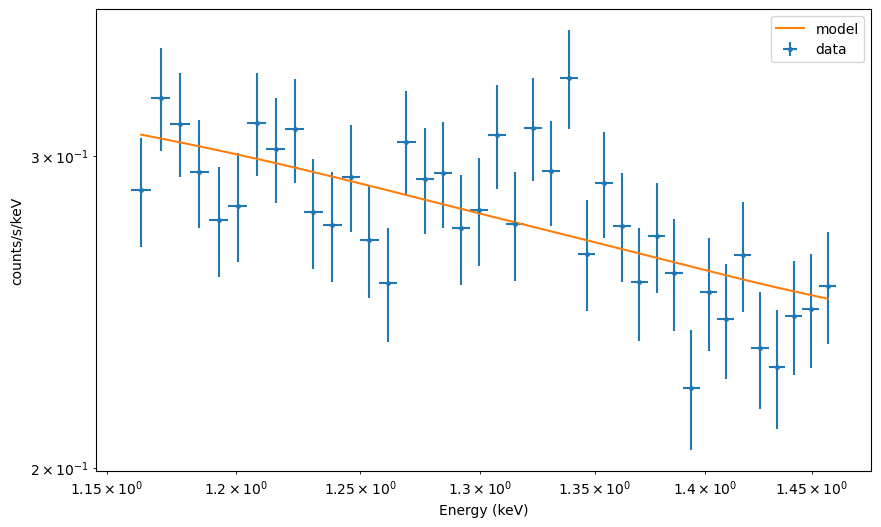

In [19]:
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()
energies = np.asarray(Plot.x())
edeltas = np.asarray(Plot.xErr())
rates = np.asarray(Plot.y())
errors = np.asarray(Plot.yErr())
foldedmodel = np.asarray(Plot.model())

#print("energies ",energies)
#print("foldedmodel ",foldedmodel)

#ax.clear()
fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
ax.plot(energies, foldedmodel,label='model')
#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

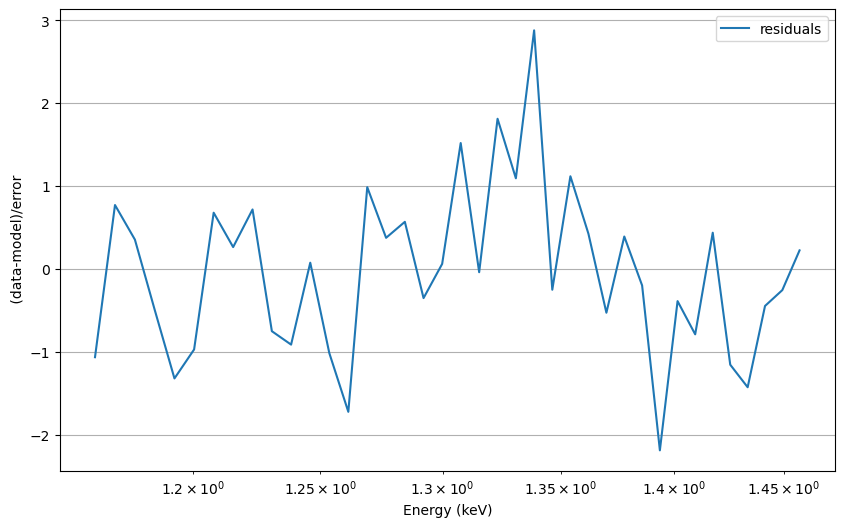

In [20]:
ax.clear()
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(energies,(rates-foldedmodel)/errors,label='residuals')
#ax.axhline(y=-3)
#ax.axhline(y=3)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r' (data-model)/error')
ax.set_xscale("log")
#ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

In [19]:
# FREE DM LINE ONLY NORM and not Position and FIT
# CHECK \sqrt( DELTA TS) to see if the DM line is significant
mpoly.gaussian.norm.frozen = False

Fit.statMethod = "cstat"
##Fit.method = "migrad"
Fit.nIterations=10000
Fit.perform()
Fit.perform()
Fit.perform()
Fit.perform()
Fit.perform()
TSDMline = Fit.statistic
dofDMline = Fit.dof
print("Test Statistics ",TSDMline," testStatistics ",Fit.testStatistic," dof ",dofDMline," nVarPars ",Fit.nVarPars)
# PUT LOOP OF FIT TO CHECK CONVERGENCE
#loopfit = 20000
#thresholdfit =0.001

TSbase = TSDMline
for i in range(0,loopfit):
    #print(i)
    Fit.perform()
    Fit.perform()
    Fit.perform()
    Fit.perform()
    Fit.perform()
    TSDMline = Fit.statistic
    dofDMline = Fit.dof
    #print("Test Statistics ",TSDMline," testStatistics ",Fit.testStatistic," dof ",dofDMline," nVarPars ",Fit.nVarPars)
    if(TSbase - TSDMline <thresholdfit):
        break
    TSbase = TSDMline
print("iterations in the loop ",i," loopfit ",loopfit)

print("Test Statistics ",TSDMline," testStatistics ",Fit.testStatistic," dof ",dofDMline," nVarPars ",Fit.nVarPars)
Xset.chatter=10
AllModels.show()
Fit.show()
Xset.chatter = 1
print("Delta TS ",TSnoDM-TSDMline," sqrt(DeltaTS) ",np.sqrt(TSnoDM-TSDMline))
normDMbf = mpoly.gaussian.norm.values[0]
print("normDMbf",normDMbf)
print(mpoly.gaussian.norm.values)
#LEVEN
#Test Statistics  39.37455789943715  testStatistics  40.151639645071626  dof  27  nVarPars  18
#Delta TS  0.001978079777700259  sqrt(DeltaTS)  0.04447560879516164
#[1.632752057772001e-06, 1.632752057772001e-08, 0.0, 0.0, 1e+20, 1e+24]

Test Statistics  30.362191042471068  testStatistics  30.268669321066547  dof  35  nVarPars  4
iterations in the loop  0  loopfit  20000
Test Statistics  30.362191042471295  testStatistics  30.268669318942642  dof  35  nVarPars  4
Delta TS  9.505448658245768  sqrt(DeltaTS)  3.083090763867611
normDMbf 0.0006575199454995286
[0.0006575199454995286, 6.575199454995286e-06, 0.0, 0.0, 1e+20, 1e+24]

Parameters defined:
Model mpoly:powerlaw<1> + powerlaw<2> + powerlaw<3> + gaussian<4> + gaussian<5> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            0.0          frozen
   2    1   powerlaw   norm                2.63228E-19  +/-  -1.00000     
   3    2   powerlaw   PhoIndex            1.00000      frozen
   4    2   powerlaw   norm                7.70937E-02  +/-  1.68266E-02  
   5    3   powerlaw   PhoIndex            2.00000      frozen
   6    3   powerlaw   norm                2.60055E-02  +/-  2.18673E-02  
   7 

Plot command list is now empty


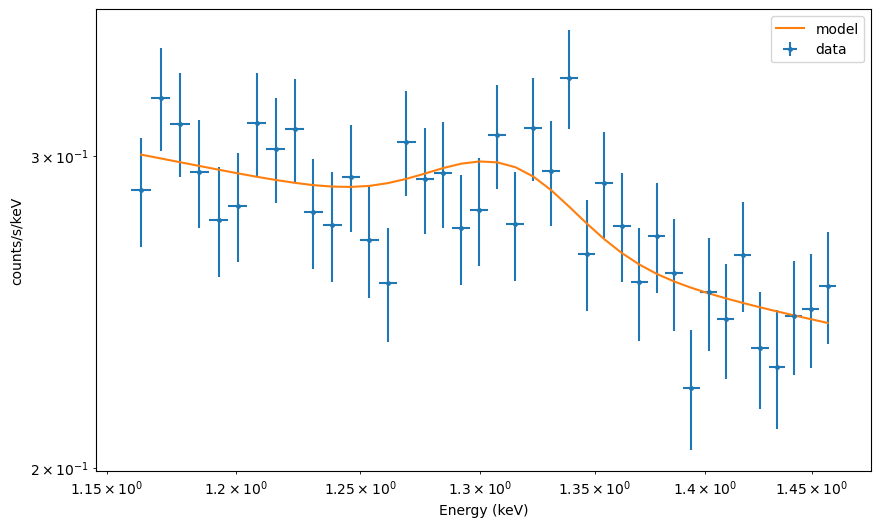

In [20]:
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()
energies = np.asarray(Plot.x())
edeltas = np.asarray(Plot.xErr())
rates = np.asarray(Plot.y())
errors = np.asarray(Plot.yErr())
foldedmodel = np.asarray(Plot.model())

#print("energies ",energies)
#print("foldedmodel ",foldedmodel)

#ax.clear()
fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
ax.plot(energies, foldedmodel,label='model')
#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

In [21]:
Plot.commands = ()
Plot.add = True
Plot.xAxis = "keV"
Plot("ldata")
#ax.clear()
energies = np.asarray(Plot.x())
edeltas = np.asarray(Plot.xErr())
rates = np.asarray(Plot.y())
errors = np.asarray(Plot.yErr())
foldedmodel = np.asarray(Plot.model())
nAddComps = int(Plot.nAddComps())
print("nAddComps ",Plot.nAddComps())
modelcomp = np.zeros((nAddComps, len(energies)))
modelcomptot = np.zeros(len(energies))
for i in range(nAddComps):
    #print(i)
    modelcomp[i] = np.asarray(Plot.addComp(i+1))
    modelcomptot = modelcomptot + modelcomp[i]

Plot command list is now empty
nAddComps  5


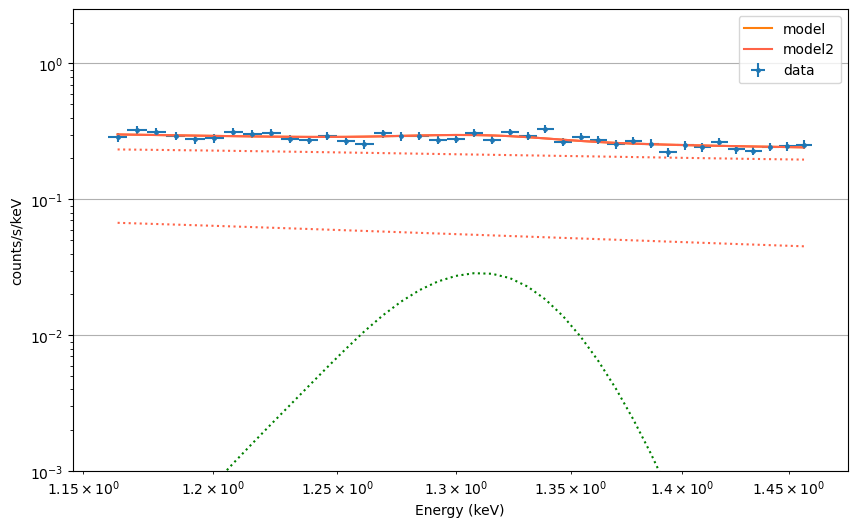

In [22]:
fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
ax.plot(energies, foldedmodel,label='model')
ax.plot(energies, modelcomptot,label='model2',linestyle='-', marker='',color='tomato')
for i in range(0,3):
    #print(i)
    ax.plot(energies, modelcomp[i][:],label='',linestyle=':', marker='',color='tomato')
for i in range(4,nAddComps):
    #print(i)
    ax.plot(energies, modelcomp[i][:],label='',linestyle=':', marker='',color='black')
#DM
ax.plot(energies, modelcomp[3][:],label='',linestyle=':', marker='',color='green')

#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim((0.001,2.5))
ax.grid()
ax.legend()

In [23]:
# NOW I WANT TO SCAN the normalization of the DM LINE
# I construct an array of normalizations: for each value I fix the DM line (norm) and find the TS best-fit value
# At the end I have an array of normalizations and TS values that I can use to compute upper limits

# A strategy to define the values of normalizations to scan 
# To be improved, still arbitrary
print("normDMbf",normDMbf)
print("normlDMhdata",normlDMhdata)
print("Maxnormline",Maxnormline)
#normlDMhdata
#Maxnormline

if normDMbf <= Maxnormline*1e-2 or normDMbf <= normlDMhdata*1e-4:
    print("NO BF")
    if(Maxnormline >0):
        normmin = Maxnormline*1e-2
        normmax = Maxnormline*1.  
    else:
        normmin = normlDMhdata*1e-3
        normmax = normlDMhdata*0.2
else:
    print("BF")
    normmin = normDMbf
    normmax = normDMbf*10.0
print("normmin ",normmin," normmax ",normmax)


nstepsDM = 10
vnormDM = np.logspace(np.log10(normmin), np.log10(normmax), num = nstepsDM)
vTSDM = np.zeros(nstepsDM)
ibrealk = 0
for inorm in range(0,len(vnormDM)):
    norm = vnormDM[inorm]
    print(norm)
    mpoly.gaussian.norm.values = norm
    mpoly.gaussian.norm.frozen = True
    Fit.statMethod = "cstat"
    Fit.nIterations=10000
    Fit.perform()
    Fit.perform()
    Fit.perform()
    Fit.perform()
    TSDMlinetest = Fit.statistic
    dofDMlinetest = Fit.dof
    TSbase = TSDMlinetest
    print("TSDMlinetest ",TSDMlinetest," TSDMline ",TSDMline)
    for i in range(0,loopfit):
        #print(i)
        Fit.perform()
        Fit.perform()
        Fit.perform()
        Fit.perform()
        Fit.perform()
        TSDMlinetest = Fit.statistic
        #print("Test Statistics ",TSDMline," testStatistics ",Fit.testStatistic," dof ",dofDMline," nVarPars ",Fit.nVarPars)
        if( np.abs(TSDMlinetest - TSbase) <thresholdfit):
            break
        TSbase = TSDMlinetest
    print("iterations in the loop ",i," loopfit ",loopfit," ",TSDMlinetest)
    vTSDM[inorm] = TSDMlinetest
    if inorm > 1 and (vTSDM[inorm] - vTSDM[inorm-1] > 0.) and vTSDM[inorm] - TSDMline > 10.:
        ibrealk = inorm
        break

if ibrealk > 0:
    for inorm in range (ibrealk,len(vnormDM)):
        vTSDM[inorm] = vTSDM[ibrealk]


normDMbf 0.0006575199454995286
normlDMhdata 0.08096460693285391
Maxnormline 0
BF
normmin  0.0006575199454995286  normmax  0.006575199454995286
0.0006575199454995286
TSDMlinetest  30.362191042471125  TSDMline  30.362191042471295
iterations in the loop  0  loopfit  20000   30.362191042471125
0.0008492196653505209
TSDMlinetest  31.146818300843847  TSDMline  30.362191042471295
iterations in the loop  0  loopfit  20000   31.146818301225835
0.001096809374307517
TSDMlinetest  34.44740632012463  TSDMline  30.362191042471295
iterations in the loop  0  loopfit  20000   34.44740632012457
0.0014165837799720584
TSDMlinetest  42.426184743273666  TSDMline  30.362191042471295
iterations in the loop  0  loopfit  20000   42.426184743273325


[0.00065752 0.00084922 0.00109681 0.00141658 0.00182959 0.002363
 0.00305194 0.00394173 0.00509094 0.0065752 ]   [30.36219104 31.1468183  34.44740632 42.42618474 42.42618474 42.42618474
 42.42618474 42.42618474 42.42618474 42.42618474]
vroots  [0.00098591]
bound  0.000985906791293971


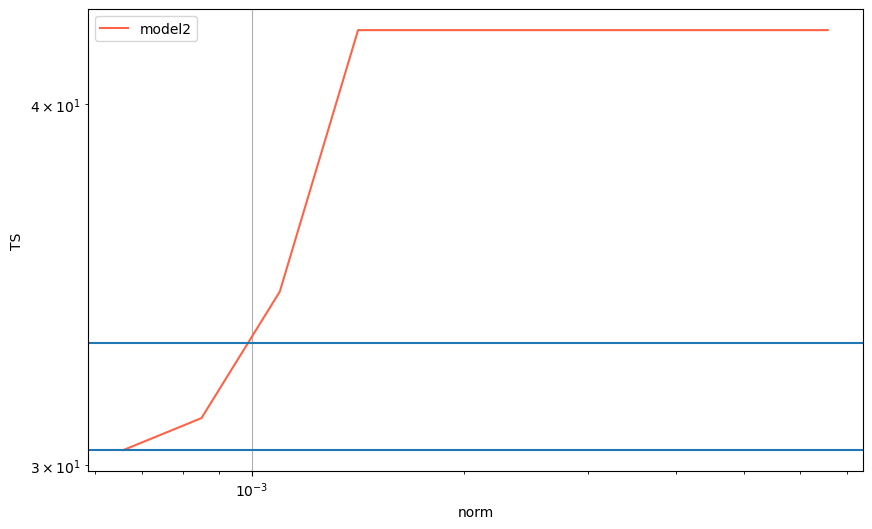

In [24]:
# WITH THE INFO ABOVE compute 95%CL (Delta TS = 2.71) upper limit


print(vnormDM," ",vTSDM)
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(vnormDM,vTSDM,label='model2',linestyle='-', marker='',color='tomato')

ax.axhline(y=TSDMline)
ax.axhline(y=TSDMline+2.71)

ax.set_xlabel('norm')
ax.set_ylabel(r'TS')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,2.5))
ax.grid()
ax.legend()

TSth = 2.71
def MTroots(vx,vy):
    vroots = []
    for i in range(1,len(vx)):
        #print("vx ",vx[i]," ",vy[i])
        #Check whether sign has changed
        if(vy[i]*vy[i-1]<0.):
            root=(vx[i]*vy[i-1]-vx[i-1]*vy[i])/(vy[i-1]-vy[i])
            #print(vx[i-1]," ",vx[i]," ",vy[i-1]," ",vy[i])
            #print("i ", i," ",root," ")
            vroots.append(root)
    return  vroots

x=np.log10(vnormDM)
y=vTSDM-TSDMline-TSth
vroots = np.pow(10.,MTroots(x,y))
bound = 0
if(len(vroots)>0):
    bound=np.max(vroots)
else:
    bound=0.
print("vroots ",vroots)
print("bound ",bound)



In [ ]:
#Nmodel = foldedmodel*exposure*DeltaE_ana
#print("min counts ",np.min(counts_ana)," ",np.min(Nmodel))
#print("max counts ",np.max(counts_ana)," ave counts ",np.mean(counts_ana))
#test = 2*(Nmodel-counts_ana+counts_ana*np.log(counts_ana/Nmodel))
#myTS = np.sum(test)
#print(myTS)
#print("Test Statistics ",Fit.statistic," testStatistics ",Fit.testStatistic," dof ",Fit.dof," nVarPars ",Fit.nVarPars)